<a href="https://colab.research.google.com/github/mudassir7328/Heart_Disease_Prediction/blob/main/hear_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

In [4]:
df = pd.read_csv("heart_disease_data.csv")

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape: (303, 14)

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [5]:
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


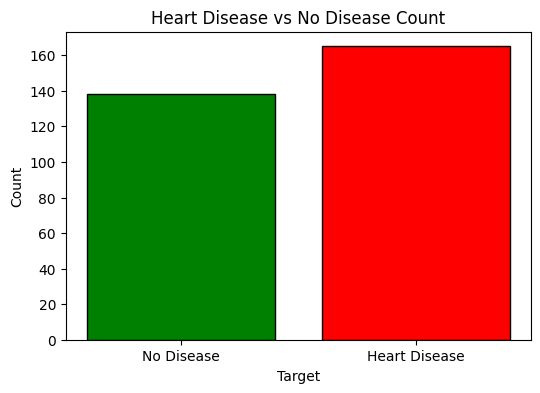

Insight: 54.5% of patients in this dataset have heart disease — the classes are fairly balanced, which affects how much you should trust accuracy alone.


In [7]:
# GRAPH 1 : Heart Disease vs No Disease Count
plt.figure(figsize=(6, 4))
plt.bar(["No Disease", "Heart Disease"],
        [sum(df["target"] == 0), sum(df["target"] == 1)],
        color=["green", "red"], edgecolor="black")
plt.title("Heart Disease vs No Disease Count")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

disease_pct = round(df["target"].mean() * 100, 1)
print(f"Insight: {disease_pct}% of patients in this dataset have heart disease — "
      f"the classes are {'fairly balanced' if 35 <= disease_pct <= 65 else 'imbalanced'}, "
      f"which affects how much you should trust accuracy alone.")

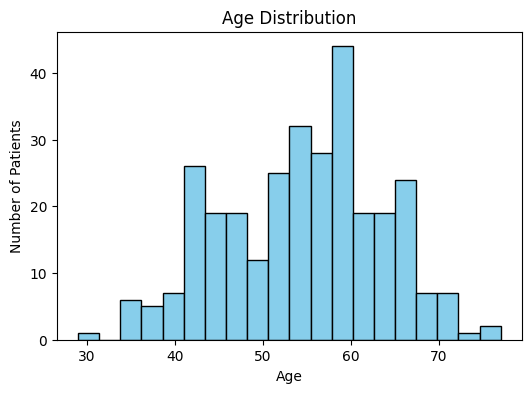

Insight: Patient ages range from 29 to 77, with most patients concentrated around 55 years old (median), which is typical for cardiac risk studies.


In [8]:
# GRAPH 2 : Age Distribution
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

print(f"Insight: Patient ages range from {df['age'].min()} to {df['age'].max()}, "
      f"with most patients concentrated around {int(df['age'].median())} years old "
      f"(median), which is typical for cardiac risk studies.")

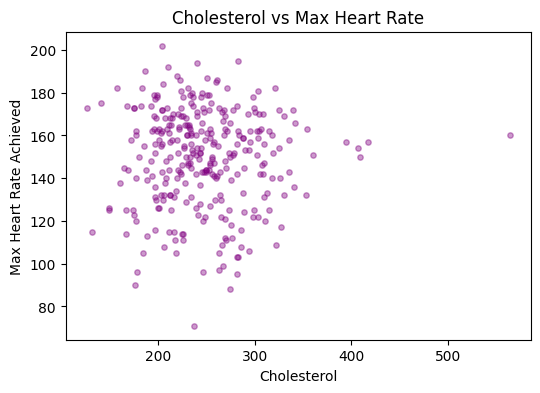

Insight: Cholesterol and Max Heart Rate have a correlation of -0.01 — only a weak relationship, suggesting cholesterol alone is not a strong predictor of max heart rate.


In [9]:
# GRAPH 3 : Cholesterol vs Max Heart Rate (thalach)
plt.figure(figsize=(6, 4))
plt.scatter(df["chol"], df["thalach"], color="purple", alpha=0.4, s=15)
plt.xlabel("Cholesterol")
plt.ylabel("Max Heart Rate Achieved")
plt.title("Cholesterol vs Max Heart Rate")
plt.show()

corr = round(df["chol"].corr(df["thalach"]), 2)
print(f"Insight: Cholesterol and Max Heart Rate have a correlation of {corr} — "
      f"{'a noticeable relationship' if abs(corr) > 0.3 else 'only a weak relationship'}, "
      f"suggesting {'cholesterol level is meaningfully linked to max heart rate' if abs(corr) > 0.3 else 'cholesterol alone is not a strong predictor of max heart rate'}.")


/tmp/ipykernel_12997/395342460.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)


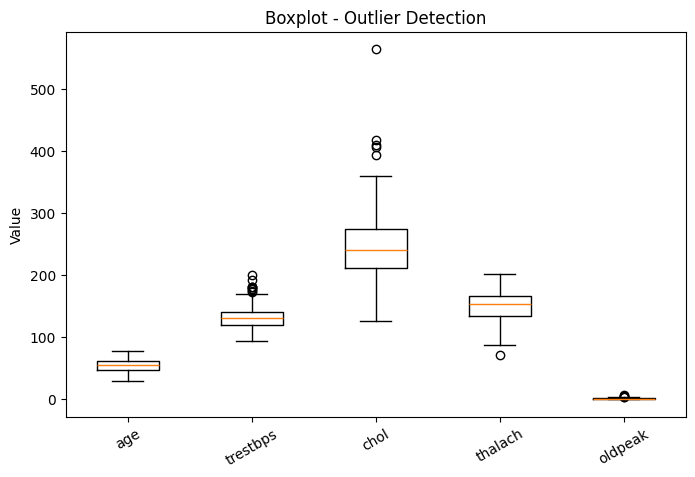

Insight:
  age            : 0 outliers (values outside 27.2 - 81.2)
  trestbps       : 9 outliers (values outside 90.0 - 170.0)
  chol           : 5 outliers (values outside 115.8 - 369.8)
  thalach        : 1 outliers (values outside 84.8 - 214.8)
  oldpeak        : 5 outliers (values outside -2.4 - 4.0)


In [10]:
# GRAPH 4 : Boxplot to Detect Outliers
outlier_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(8, 5))
plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)
plt.title("Boxplot - Outlier Detection")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.show()

print("Insight:")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col:15s}: {outlier_count} outliers (values outside {round(lower,1)} - {round(upper,1)})")


In [11]:
# Remove Outliers using IQR method
print(f"\nShape before removing outliers: {df.shape}")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Shape after removing outliers: {df.shape}")


Shape before removing outliers: (303, 14)
Shape after removing outliers: (284, 14)


In [12]:
X = df.drop(columns=["target"])   # Features
y = df["target"]                  # Target (0 = No Disease, 1 = Heart Disease)

print("\nFeatures (X):")
print(X.columns.tolist())
print("\nTarget (y):", y.name)
print("Target Distribution:")
print(y.value_counts())


Features (X):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target (y): target
Target Distribution:
target
1    159
0    125
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining Size : {X_train.shape}")
print(f"Testing  Size : {X_test.shape}")


Training Size : (227, 13)
Testing  Size : (57, 13)


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nScaling Done!")


Scaling Done!


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 3))
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred), 3))


Logistic Regression Accuracy: 0.86
Random Forest Accuracy: 0.842


In [16]:
print("\nSample Predictions (first 10):")
print(y_pred[:10])



Sample Predictions (first 10):
[1 0 1 0 1 0 1 0 1 0]


In [17]:
comparison = pd.DataFrame({
    "Actual"    : y_test.iloc[:10].values,
    "Predicted" : np.round(y_pred[:10], 2),
    "Result"    : ["Correct" if a == p else "Wrong"
                   for a, p in zip(y_test.iloc[:10], y_pred[:10])]
})

print("\nActual vs Predicted (first 10 rows):")
print(comparison.to_string(index=False))


Actual vs Predicted (first 10 rows):
 Actual  Predicted  Result
      1          1 Correct
      0          0 Correct
      1          1 Correct
      0          0 Correct
      1          1 Correct
      0          0 Correct
      0          1   Wrong
      0          0 Correct
      1          1 Correct
      0          0 Correct


In [18]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("---------MODEL PERFORMANCE STATS---------")
print(f"  Accuracy  : {round(accuracy  * 100,2)}%")
print(f"  Precision : {round(precision * 100,2)}%")
print("Recall :", recall)
print("F1 Score:", f1)

---------MODEL PERFORMANCE STATS---------
  Accuracy  : 84.21%
  Precision : 84.38%
Recall : 0.8709677419354839
F1 Score: 0.8571428571428571


In [19]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\n  True  Negative  (Correctly predicted No Disease)   : {cm[0][0]}")
print(f"  False Positive  (Wrongly predicted Heart Disease)  : {cm[0][1]}")
print(f"  False Negative  (Wrongly predicted No Disease)     : {cm[1][0]}")
print(f"  True  Positive  (Correctly predicted Heart Disease): {cm[1][1]}")


Confusion Matrix:
[[21  5]
 [ 4 27]]

  True  Negative  (Correctly predicted No Disease)   : 21
  False Positive  (Wrongly predicted Heart Disease)  : 5
  False Negative  (Wrongly predicted No Disease)     : 4
  True  Positive  (Correctly predicted Heart Disease): 27


In [20]:
print("\n--- Predict New Patient ---")
age      = float(input("Enter Age                                  : "))
sex      = float(input("Enter Sex (1 = Male, 0 = Female)           : "))
cp       = float(input("Enter Chest Pain Type (0-3)                : "))
trestbps = float(input("Enter Resting Blood Pressure               : "))
chol     = float(input("Enter Cholesterol                          : "))
fbs      = float(input("Fasting Blood Sugar > 120 (1 = Yes, 0 = No): "))
restecg  = float(input("Enter Resting ECG Result (0-2)             : "))
thalach  = float(input("Enter Max Heart Rate Achieved              : "))
exang    = float(input("Exercise Induced Angina (1 = Yes, 0 = No)  : "))
oldpeak  = float(input("Enter ST Depression (oldpeak)              : "))
slope    = float(input("Enter Slope of ST Segment (0-2)            : "))
ca       = float(input("Enter No. of Major Vessels (0-4)           : "))
thal     = float(input("Enter Thal (0-3)                           : "))

new_input = scaler.transform([[age, sex, cp, trestbps, chol, fbs,
                                restecg, thalach, exang, oldpeak,
                                slope, ca, thal]])

result = model.predict(new_input)

print("\n========================================")
if result[0] == 1:
    print("  Prediction : Heart Disease Detected")
else:
    print("  Prediction : No Heart Disease")
print("========================================")


--- Predict New Patient ---
Enter Age                                  : 17
Enter Sex (1 = Male, 0 = Female)           : 1
Enter Chest Pain Type (0-3)                : 0
Enter Resting Blood Pressure               : 145
Enter Cholesterol                          : 233    
Fasting Blood Sugar > 120 (1 = Yes, 0 = No): 0 
Enter Resting ECG Result (0-2)             : 0      
Enter Max Heart Rate Achieved              : 150      
Exercise Induced Angina (1 = Yes, 0 = No)  : 0      
Enter ST Depression (oldpeak)              : 2.3      
Enter Slope of ST Segment (0-2)            : 0
Enter No. of Major Vessels (0-4)           : 0
Enter Thal (0-3)                           : 1

  Prediction : Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
